# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is called linear based on how the coefficients (the betas) are used. It is linear if the coefficients are just multiplied by variables and added together.

The variables themselves can be changed (like squared), and the model is still linear.

For example:
- Linear: $y = β0 + β1x + β2x²  $
- Not linear: $y = β0 + e^(β1x)$

So, the model is linear in the coefficients (the betas), not necessarily in the variables.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

A dummy variable coefficient shows how much a group differs from the baseline (the category that is left out). The intercept represents the baseline group, and each coefficient tells you how much higher or lower another group is compared to it.

3. Can linear regression be used for classification? Explain why, or why not.

Yes, you can use it, but it is not a great choice. Classification problems usually involve predicting something like yes/no or 0/1. Linear regression can give predictions outside of that range (like negative numbers or numbers above 1), which does not make sense for probabilities. That is why other models, like logistic regression, are usually better for classification.

4. What are signs that your linear model is over-fitting?

Overfitting happens when a model learns the training data too well, including the random noise. A big sign of this is when the model performs really well on the training data but much worse on new data. This means it is not generalizing well. It often happens when the model is too complicated for the amount of data you have.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity happens when two or more predictors are very similar to each other. In other words, one variable can almost be predicted using the others. If you try to estimate their effects at the same time, it becomes hard to tell which variable is actually responsible for the change. This makes the results less reliable and harder to interpret.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

If the relationship between variables is nonlinear, you can still use linear regression by transforming the variables. For example, you can square a variable, take its log, or combine variables together. This helps the model capture curves or more complex patterns while still using a linear framework.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope tells you how much the outcome is expected to change when the input increases by one unit. For example, if the slope is 2, then increasing the input by 1 increases the predicted outcome by 2, assuming everything else stays the same.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split divides the data into two parts: one to build the model and one to test it. This is simple but depends on how the data was split. K-fold cross validation splits the data into multiple parts and repeats the process several times, then averages the results. This gives a more reliable measure of how well the model performs.

9. How is the $k$ in $k$-fold cross validation typically selected?

The value of k is usually chosen to be 5 or 10. These values work well in practice because they give a good balance between accuracy and how long the computation takes. Ten is especially common because it tends to give stable results.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [3]:
df.columns
df = df.rename(columns={"Review Scores Rating": "Review_Scores_Rating", "Neighbourhood ": "Neighbourhood"})

In [4]:
df.groupby("Neighbourhood")[["Price", "Review_Scores_Rating"]].mean()

,Price,Review_Scores_Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhattan is the most expensive on average.

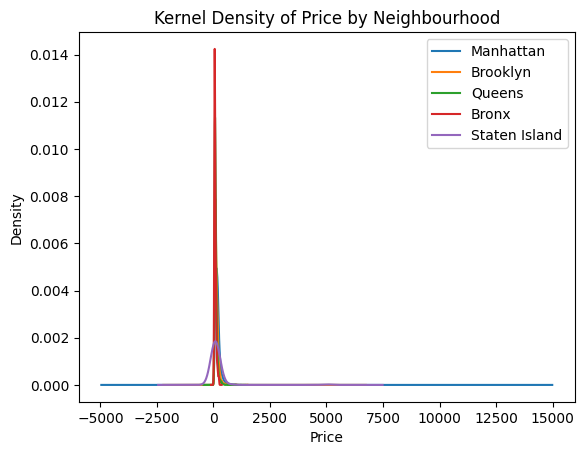

In [12]:
for n in df["Neighbourhood"].unique():
    subset = df[df["Neighbourhood"] == n]
    subset["Price"].plot(kind="density", label=n)

plt.title("Kernel Density of Price by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.show()

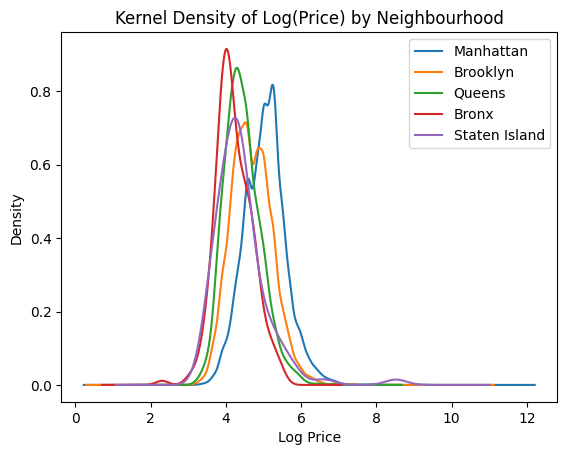

In [13]:
df["log_price"] = np.log(df["Price"])

for n in df["Neighbourhood"].unique():
    subset = df[df["Neighbourhood"] == n]
    subset["log_price"].plot(kind="density", label=n)

plt.title("Kernel Density of Log(Price) by Neighbourhood")
plt.xlabel("Log Price")
plt.legend()
plt.show()

In [16]:
import statsmodels.api as sm
import pandas as pd

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int) #drop first category

X = sm.add_constant(dummies)   #keep intercept
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        23:40:34   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

The intercept equals the omitted group mean, and each coefficient measures the difference from that mean, so intercept + coefficient gives the group mean.

In [17]:
import statsmodels.api as sm

X = sm.add_constant(df["Review_Scores_Rating"])
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        23:44:39   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

The slope coefficient on Review Scores Rating is 1.0208, indicating that a one-point increase in review score is associated with an approximate $1.02 increase in predicted price on average. This suggests a positive relationship between review quality and price, though the magnitude is modest.

In [18]:
import statsmodels.api as sm
import pandas as pd

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int)

X = pd.concat([df["Review_Scores_Rating"], dummies], axis=1)
X = sm.add_constant(X)

y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        23:50:46   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

The slope coefficient on Review Scores Rating increases slightly from 1.02 to 1.08 after adding neighbourhood controls. This suggests that once we compare listings within the same neighbourhood, the relationship between review scores and price becomes slightly stronger.

The neighbourhood coefficients change slightly after adding review scores, but remain very similar. Previously, they represented differences in average prices across neighbourhoods. After including review scores, they represent differences in prices across neighbourhoods holding review scores constant. The small changes suggest that review scores do not differ dramatically across neighbourhoods, so the adjustment is minor.

In [19]:
import statsmodels.formula.api as smf

model = smf.ols("Price ~ Review_Scores_Rating * C(Neighbourhood)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:02:59   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

The slopes are broadly similar across most neighbourhoods, indicating a consistent positive relationship between review scores and price. Staten Island appears as an outlier with an unstable estimate, but overall the marginal effect of review scores does not vary much by neighbourhood.

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

y = df["Price"]

X4 = df[["Review_Scores_Rating"]] #review only

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True) #review + neighbourhood
X5 = pd.concat([df["Review_Scores_Rating"], dummies], axis=1)

X6 = X5.copy()
for col in dummies.columns:
    X6[col + "_int"] = df["Review_Scores_Rating"] * dummies[col] #interaction

def get_rmse(X):
    scores = cross_val_score(LinearRegression(), X, y, cv=10, scoring="neg_mean_squared_error")
    return np.sqrt(-scores.mean())

print("Model 4:", get_rmse(X4))
print("Model 5:", get_rmse(X5))
print("Model 6:", get_rmse(X6))

Model 4: 148.6360255412211
Model 5: 145.24166866723286
Model 6: 146.01732248841878


Model 5 performs best (lowest RMSE), showing that neighbourhood improves prediction. Model 6 adds complexity without improving performance, suggesting overfitting.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [22]:
import pandas as pd

df = pd.read_csv('cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [24]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


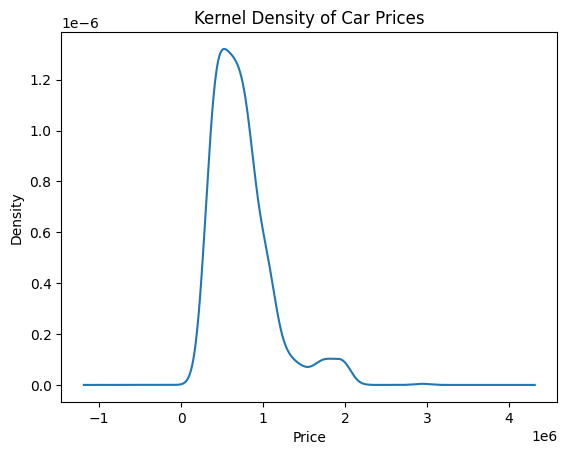

In [26]:
df["Price"].plot(kind="density")
plt.title("Kernel Density of Car Prices")
plt.xlabel("Price")
plt.show()

In [27]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


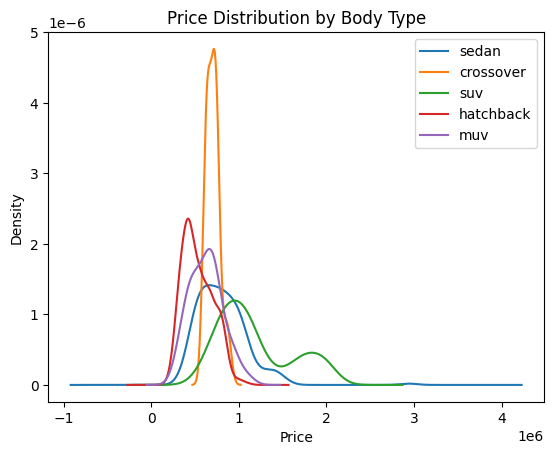

In [28]:
for b in df["Body_Type"].unique():
    subset = df[df["Body_Type"] == b]
    subset["Price"].plot(kind="density", label=b)

plt.title("Price Distribution by Body Type")
plt.xlabel("Price")
plt.legend()
plt.show()

SUVs are the most expensive and have the greatest variance, while hatchbacks are the least expensive. Crossovers show the lowest variability. The density plot confirms that SUVs are both higher priced and more spread out.

In [29]:
import statsmodels.api as sm

X = sm.add_constant(df["Seating_Capacity"])
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0245
Time:                        00:21:26   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

The slope coefficient on Seating Capacity is about $59,270, meaning each additional seat is associated with an average increase of 59,270 in price.

In [33]:
dummies = pd.get_dummies(df["Seating_Capacity"].astype(str), drop_first=True, dtype=int)

X = sm.add_constant(dummies).astype(float)
y = df["Price"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000267
Time:                        00:26:49   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

Although price increases with seating capacity on average, the categorical model shows that the relationship is not linear, with uneven jumps across seat categories.

In [34]:
df["Age"] = 2026 - df["Make_Year"]

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import numpy as np

X = df[["Age"]]
y = df["Price"]

for d in range(1, 6):
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    scores = cross_val_score(model, X, y, cv=10, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-scores.mean())
    print("Degree", d, "RMSE:", rmse)

Degree 1 RMSE: 316694.4427669286
Degree 2 RMSE: 317513.1817679724
Degree 3 RMSE: 316828.28644538444
Degree 4 RMSE: 316977.01986279595
Degree 5 RMSE: 316435.37443498604


Although the differences in RMSE across models are relatively small, the degree 5 model performs best, suggesting that the relationship between vehicle age and price is somewhat nonlinear. However, the small improvement also indicates that higher-order terms only provide modest gains in predictive accuracy.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


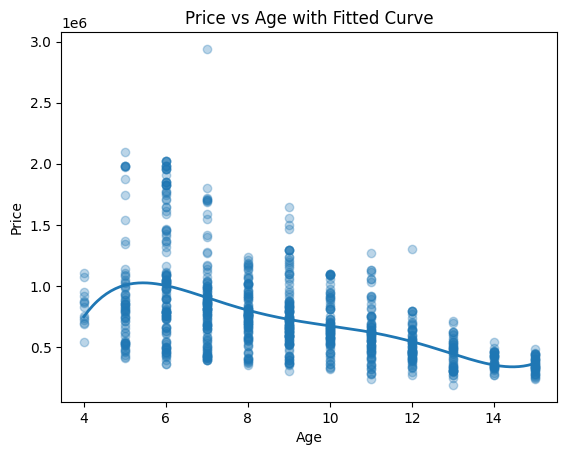

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[["Age"]]
y = df["Price"]

model = make_pipeline(PolynomialFeatures(5, include_bias=False), LinearRegression())
model.fit(X, y)

age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 200).reshape(-1, 1)
pred = model.predict(age_grid)

plt.scatter(df["Age"], df["Price"], alpha=0.3)
plt.plot(age_grid, pred, linewidth=2)

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Fitted Curve")
plt.show()

The model captures the overall decline in price with age, including a slight early increase, but there is significant variation in prices, so it fits the general trend but not all observations.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [36]:
import pandas as pd

df = pd.read_csv('heart_hw.csv')
df

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0
...,...,...,...,...
98,99,30,control,1
99,100,48,treatment,1
100,101,40,treatment,1
101,102,48,treatment,1


In [37]:
control = df[df["transplant"] == "control"]["y"].mean()
treatment = df[df["transplant"] == "treatment"]["y"].mean()
ate = treatment - control

print("Control:", control)
print("Treatment:", treatment)
print("ATE:", ate)

Control: 0.11764705882352941
Treatment: 0.34782608695652173
ATE: 0.23017902813299232


This means that receiving a heart transplant increases the probability of three-year survival by approximately 23 percentage points.

In [38]:
import statsmodels.api as sm

df["treat"] = (df["transplant"] == "treatment").astype(int)

X = sm.add_constant(df["treat"])
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        00:55:18   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

In the regression of survival on transplant status, the intercept is 0.1176, which corresponds exactly to the survival rate in the control group (approximately 0.118). The coefficient on the transplant variable is 0.2302, which matches the difference in survival rates between the treatment and control groups computed earlier (the ATE). This confirms that the regression coefficient on the treatment indicator is equal to the average treatment effect.

In [39]:
import statsmodels.api as sm

X = sm.add_constant(df[["treat", "age"]])
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        00:57:52   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

When controlling for age, the coefficient on transplant increases from 0.230 to 0.265. This suggests that age was negatively confounding the relationship between transplant and survival. Since older patients are less likely to survive and may be more likely to receive transplants, failing to control for age led to an underestimate of the true treatment effect. After controlling for age, the estimated impact of a transplant becomes larger.

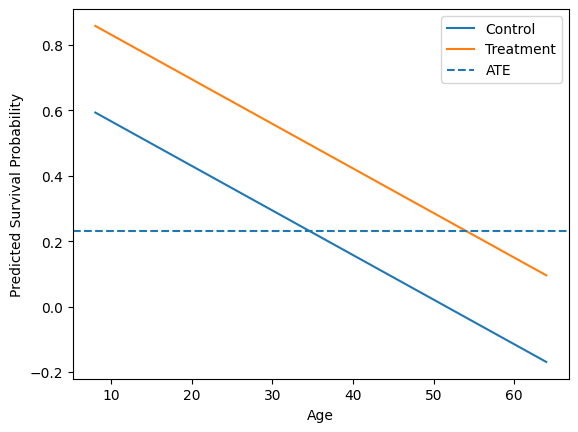

In [40]:
import numpy as np
import matplotlib.pyplot as plt

age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model.predict(pd.DataFrame({
    "const": 1,
    "treat": 0,
    "age": age_grid
}))

pred_treat = model.predict(pd.DataFrame({
    "const": 1,
    "treat": 1,
    "age": age_grid
}))

plt.plot(age_grid, pred_control, label="Control")
plt.plot(age_grid, pred_treat, label="Treatment")

plt.axhline(y=0.230, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

Because the model-implied treatment effect (0.265) exceeds the ATE (0.230), the ATE lies below the true treatment effect at all ages in the plot. This indicates that the ATE understates the impact of transplantation, reflecting the influence of age as a confounding variable.

In [41]:
import statsmodels.formula.api as smf

model = smf.ols("y ~ treat * age", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        01:03:24   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3549      0.280      1.269      0.2

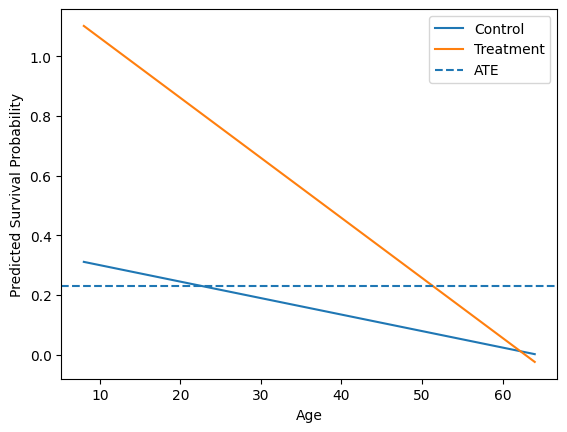

In [42]:
import numpy as np
import matplotlib.pyplot as plt

age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model.predict(pd.DataFrame({
    "treat": 0,
    "age": age_grid
}))

pred_treat = model.predict(pd.DataFrame({
    "treat": 1,
    "age": age_grid
}))

plt.plot(age_grid, pred_control, label="Control")
plt.plot(age_grid, pred_treat, label="Treatment")

plt.axhline(y=0.230, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

With the interaction, the treatment effect decreases with age. Transplants are much more beneficial for younger patients, and the ATE overestimates the effect for older patients while underestimating it for younger patients.

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

y = df["y"]

X1 = df[["treat"]]
X2 = df[["treat", "age"]]
X3 = X2.copy()
X3["treat_age"] = df["treat"] * df["age"]

def rmse(X):
    scores = cross_val_score(LinearRegression(), X, y, cv=10, scoring="neg_mean_squared_error")
    return np.sqrt(-scores.mean())

print("Model 1:", rmse(X1))
print("Model 2:", rmse(X2))
print("Model 3:", rmse(X3))

Model 1: 0.4579331533076079
Model 2: 0.4463497064996494
Model 3: 0.4428296668034193


Adding age improves prediction, and including the interaction provides further improvement, making Model 3 the best-performing model.

The model may suffer from omitted variable bias and does not capture all relevant health factors, so its estimates may not reflect true causal effects. It could also introduce fairness concerns by prioritizing younger patients and reinforcing existing biases. Therefore, it should not be used alone for high-stakes decisions like transplant allocation.